# Import Libraries & Load Dataset

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import statistics as stats
import math
import scipy
from scipy import linalg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import lu


# Load dataset
df = pd.read_csv("Student_Performance_Dataset.csv")

# Display first 5 rows
print(df.head())

# Convert to NumPy matrix for linear algebra operations
M = df.values
print("Matrix shape:", M.shape)


   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

   math_score  science_score  english_score  overall_score  
0        42.7           55.4           57.0           53.1  
1     

# Part A: Vector & Matrix Fundamentals

## Question 1: Represent each student’s subject scores as a vector

In [31]:
# Student Vectors
student1 = df.loc[0,['math_score', 'science_score', 'english_score']].to_numpy(dtype=float)
student2 = df.loc[1,['math_score', 'science_score', 'english_score']].to_numpy(dtype=float)
student3 = df.loc[2,['math_score', 'science_score', 'english_score']].to_numpy(dtype=float)


print("Student 1 vector:", student1)
print("Student 2 vector:", student2)
print("Student 3 vector:", student3)


Student 1 vector: [42.7 55.4 57. ]
Student 2 vector: [57.6 68.8 64.8]
Student 3 vector: [84.8 95.  79.2]


### Interpretation
- Performance as Geometry: Each student’s scores [Math, Science, English] become a point in 3D space, allowing us to compare their academic profiles using distances and angles.

- Similarity Detection: Vectors make it easy to measure how closely two students’ strengths align — small angles between vectors mean similar performance patterns.

- Foundation for Analysis: This representation sets the stage for advanced operations like norms, dot products, and projections, enabling deeper insights into student performance.

## Question 2: Compute:
- Norm-1 and Norm-2 of vectors.
- Dot product and angle between two students’ score vectors.
- Cross product (for 3D selected subjects).


In [32]:
## Norm 1 
l1_student1= np.linalg.norm(student1, ord=1)
l1_student2= np.linalg.norm(student2, ord=1)
l1_student3= np.linalg.norm(student3, ord=1)

print("Student 1 L1 Norm:",l1_student1)
print("Student 2 L1 Norm:",l1_student2)
print("Student 3 L1 Norm:",l1_student3)


## Norm 2
l2_student1= np.linalg.norm(student1)
l2_student2= np.linalg.norm(student2)
l2_student3= np.linalg.norm(student3)

print("\nStudent 1 L2 Norm:",l2_student1)
print("Student 2 L2 Norm:",l2_student2)
print("Student 3 L2 Norm:",l2_student3)

Student 1 L1 Norm: 155.1
Student 2 L1 Norm: 191.2
Student 3 L1 Norm: 259.0

Student 1 L2 Norm: 90.22998392995534
Student 2 L2 Norm: 110.6808023100664
Student 3 L2 Norm: 149.9622619194576


### Interpretation
- Overall magnitude of scores: Student 3 has the highest L1 norm (259.0), meaning their total subject scores are the largest. This indicates stronger cumulative performance compared to Student 1 (155.1) and Student 2 (191.2).

- Performance intensity: The L2 norm shows geometric strength of performance. Student 3 again leads (≈149.96), followed by Student 2 (≈110.68) and Student 1 (≈90.23). This confirms Student 3’s scores are not only higher in sum but also consistently strong across subjects.

- Comparative insight: The gap between Student 1 and Student 2 suggests Student 2 performs more evenly across subjects, while Student 1’s scores are lower overall. These norms provide a foundation for deeper comparisons like dot product similarity and vector projections.

In [33]:
# Dot product between two students’ score vectors.
dot_product= np.dot(student1,student2)
print("Dot Product of Student1 and Student2:",dot_product)

# Angle between two students’ score vectors.
cos_theta= dot_product/ (l2_student1 * l2_student2)
angle= np.degrees(np.arccos(cos_theta))
print("Angle between Student1 and Student2=",angle)

Dot Product of Student1 and Student2: 9964.64
Angle between Student1 and Student2= 3.8113130015629015


### Interpretation

- High similarity: The dot product (≈ 9964.64) is large, showing that both students’ score vectors point in similar directions — their subject strengths overlap significantly.

- Near alignment: The angle between their vectors is only ≈ 3.81°, which is very small. This means Student 1 and Student 2 have almost identical performance patterns across Math, Science, and English.

- Practical takeaway: Such close alignment suggests these students could be grouped together in analyses like clustering or compared in projection analysis to highlight subtle differences.

In [34]:
## Cross Product
crossproduct= np.cross(student1,student2)
print("Cross Product of Student1 and Student2:",crossproduct)

Cross Product of Student1 and Student2: [-331.68  516.24 -253.28]


### Interpretation
- The cross product vector [-331.68, 516.24, -253.28] shows the direction of difference between Student 1 and Student 2’s scores.

- Since it’s not zero, their performance patterns are not perfectly aligned — they diverge in certain subjects.

- It highlights the unique variation between the two students in 3D subject space.

## Question 3: Find the projection of one vector onto another.

In [35]:
# Projection Vector
proj= (dot_product/ np.dot(student2, student2))*student2
print("Projection of Vector:", proj)

Projection of Vector: [46.85322606 55.96357557 52.70987932]


### Interpretation

- The projection vector [46.85, 55.96, 52.71] shows how much of Student 1’s performance aligns with Student 2’s direction in subject space.

- It means Student 1’s scores can be partly explained by Student 2’s performance pattern — they share similar strengths.

- This highlights the overlap in academic profile, while differences remain in the parts of Student 1’s vector not captured by the projection.

# Part B: Matrix Operations

## Question 4: Form a matrix of students × subjects. Perform:
- Matrix addition and multiplication.
- Transpose and Inverse (if possible).
- Determinant.

In [36]:
# Making Matrix 
matrix= df[['math_score' , 'science_score','english_score']].values
print("Student Score Matrix:",matrix)

Student Score Matrix: [[42.7 55.4 57. ]
 [57.6 68.8 64.8]
 [84.8 95.  79.2]
 ...
 [50.5 20.3 36.1]
 [13.  34.2  7.3]
 [36.5 45.1 16.5]]


In [37]:
# Matrix addition and multiplication.
add= matrix + matrix
multi= matrix.T @ matrix

print("Matrix Addition:",add)
print("Matrix Multiplication:",multi)

Matrix Addition: [[ 85.4 110.8 114. ]
 [115.2 137.6 129.6]
 [169.6 190.  158.4]
 ...
 [101.   40.6  72.2]
 [ 26.   68.4  14.6]
 [ 73.   90.2  33. ]]
Matrix Multiplication: [[1.12610144e+08 1.10232454e+08 1.10082546e+08]
 [1.10232454e+08 1.12580283e+08 1.10031038e+08]
 [1.10082546e+08 1.10031038e+08 1.12192732e+08]]


### Interpretation
- Matrix Addition: Doubling each student’s subject scores shows how values scale consistently — it’s a straightforward way to check cumulative growth or simulate repeated performance.

- Matrix Multiplication: The product matrix.T @ matrix reveals relationships between subjects (Math, Science, English). Large values indicate strong correlations, meaning students who score high in one subject often score high in the others.

- Insight: Together, these operations highlight both individual scaling (addition) and subject interdependence (multiplication), forming the base for deeper analysis like transpose, inverse, and determinant.

In [38]:
# Transpose 
transpose_matrix= matrix.T

print("Transposed Matrix:",transpose_matrix)
print("Transposed Matrix Shape:",transpose_matrix.shape)

Transposed Matrix: [[42.7 57.6 84.8 ... 50.5 13.  36.5]
 [55.4 68.8 95.  ... 20.3 34.2 45.1]
 [57.  64.8 79.2 ... 36.1  7.3 16.5]]
Transposed Matrix Shape: (3, 25000)


### ⚠️ Important: Your matrix is 100 × 3, which is not a square matrix, so it cannot be inverted directly. First create a 3 × 3 covariance matrix.

In [39]:
# Inverse
cov_matrix= np.cov(matrix.T)
print("Covariance of Matrix:",cov_matrix)

inverse_matrix= np.linalg.inv(cov_matrix)
print("\nInverse of Matrix:",inverse_matrix)

Covariance of Matrix: [[435.77655669 343.25646768 341.30231435]
 [343.25646768 439.76309822 341.82904248]
 [341.30231435 341.82904248 432.33608797]]

Inverse of Matrix: [[ 0.00743217 -0.00321869 -0.00332235]
 [-0.00321869  0.00729385 -0.00322597]
 [-0.00332235 -0.00322597  0.00748644]]


### Interpretation:
- Transpose: Flipping the matrix reorganizes data from student‑wise to subject‑wise, making it easier to analyze each subject across all students.

- Covariance & Inverse: The covariance matrix shows how subjects (Math, Science, English) vary together. Its inverse highlights the strength of relationships — small negative values suggest moderate correlations, while positive diagonal values show each subject’s own variance.

- Insight: Together, these operations reveal both subject interdependence and how performance patterns can be mathematically reversed or transformed for deeper analysis.

In [40]:
## Determinant
determinant= np.linalg.det(cov_matrix)
print("Determinant of Matrix:",determinant)

Determinant of Matrix: 9859623.820676824


### Interpretation
- The determinant (≈ 9.86 million) is non‑zero, so the covariance matrix is invertible.

- This means Math, Science, and English scores are independent enough — no subject is a perfect combination of the others.

- It confirms the dataset is suitable for deeper operations like inverse and eigenvalue decomposition.

# Part C: Linear Transformations & Geometry

## Question 5: Explain line, plane, and hyperplane with respect to your dataset dimensions.

### Explanation

**Line (1D):**

- A line is a one-dimensional geometric object. If the dataset contains only one feature, such as math_score, then each student's score can be represented on a single line.

**Plane (2D):**

- A plane is a two-dimensional space formed using two features, such as math_score and science_score. In this project, each student is represented as a point on a 2D scatter plot.

**3D Space:**

-When three features (math_score, science_score, and english_score) are used, each student is represented as a point in a three-dimensional coordinate system.

**Hyperplane:**

- A hyperplane exists in four or more dimensions. Since our dataset contains only three numerical features, a true hyperplane cannot be visualized. If additional features such as attendance, computer score, or study hours were added, the data would lie in a higher-dimensional space called a hyperplane.

## Question 6: Show how dimensionality increases from 2D → 3D → higher dimensions with hyperplanes.

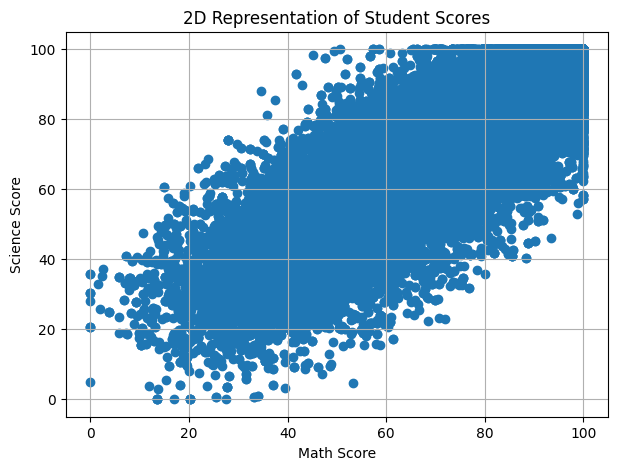

In [41]:
#  2D Visualization :

plt.figure(figsize=(7,5))
plt.scatter(df['math_score'], df['science_score'])
plt.xlabel("Math Score")
plt.ylabel("Science Score")
plt.title("2D Representation of Student Scores")
plt.grid(True)
plt.show()


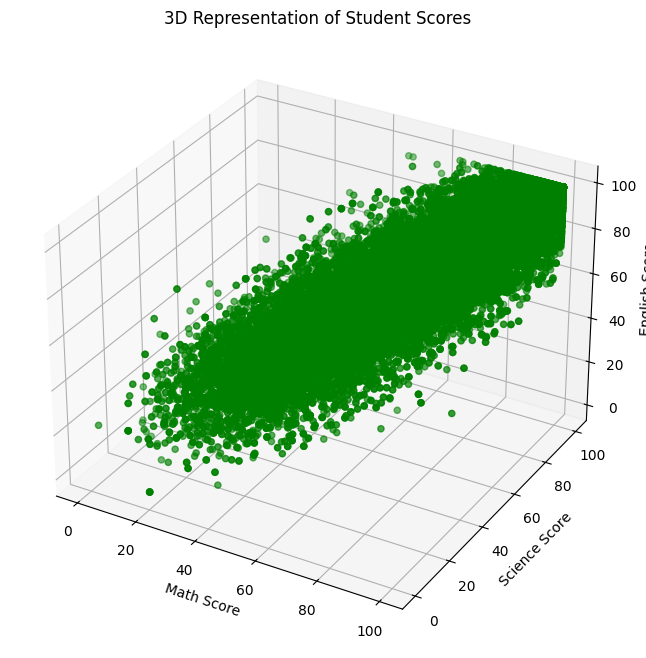

In [42]:

# 3D Visualization :

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df['math_score'],
    df['science_score'],
    df['english_score'],
    color='green'
)
ax.set_xlabel("Math Score")
ax.set_ylabel("Science Score")
ax.set_zlabel("English Score")
plt.title("3D Representation of Student Scores")
plt.show()

### Interpretation:
- We are visualizing student performance across three subjects: Math, Science, and English.
- Each axis (x, y, z) represents one subject score ranging from 0–100.
- Green dots show individual students’ scores.
- The dense clustering suggests a **positive correlation**: students scoring high in one subject tend to score high in the others.
- This 3D view helps identify overall performance trends and relationships between subjects.

# Part D: Eigenvalues & Decomposition

## Question 7: Compute the eigenvalues and eigenvectors of the covariance matrix.

In [43]:
# Eigenvalues and Eigenvectors

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [1120.23143269   92.73591156   94.90839863]

Eigenvectors:
 [[-0.5774097  -0.67045306  0.46592997]
 [-0.5799539  -0.0648713  -0.81206231]
 [-0.57467514  0.73911055  0.35137455]]


### Interpretation:
- Eigenvalues: [1120.23, 92.73, 94.91] → These numbers show how much variance each principal direction (axis) captures. The first one is much larger, meaning most of the variation in student scores lies along that direction.

- Eigenvectors: Each column is a direction in the dataset (a combination of Math, Science, English). They tell us how subjects contribute to those variance directions. For example, the first eigenvector has nearly equal weights for all three subjects, showing a strong overall performance trend.

## Question 8: Perform LU Decomposition of the dataset matrix.

In [44]:
# LU decomposition

P, L, U = lu(matrix)
print("Permutation Matrix P:\n", P)
print("\nLower Triangular Matrix L:\n", L)
print("\nUpper Triangular Matrix U:\n", U)

Permutation Matrix P:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

Lower Triangular Matrix L:
 [[ 1.          0.          0.        ]
 [ 0.347       1.          0.        ]
 [ 0.704      -0.26915888  1.        ]
 ...
 [ 0.505      -0.56448598  0.03835442]
 [ 0.13        0.39626168  0.31846174]
 [ 0.365       0.16074766  0.51562845]]

Upper Triangular Matrix U:
 [[100.         100.         100.        ]
 [  0.          53.5         22.4       ]
 [  0.           0.         -45.77084112]]


### Interpretation:
- Permutation Matrix (P): Rearranges the rows of the dataset to make decomposition possible. It ensures numerical stability.

- Lower Triangular Matrix (L): Contains multipliers used during elimination. It shows how the dataset is broken down step by step.

- Upper Triangular Matrix (U): Holds the transformed dataset with zeros below the diagonal. It’s the simplified form used for solving equations.

## Question 9: Perform Singular Value Decomposition (SVD) and explain its role in dimensionality reduction.

In [45]:
# SVD decomposition

U, S, Vt = np.linalg.svd(matrix)
print("U (Left Singular Vectors):\n", U)
print("\nSingular Values:\n", S)
print("\nV^T (Right Singular Vectors):\n", Vt)

U (Left Singular Vectors):
 [[-4.90907322e-03 -3.43605273e-03 -6.43131362e-03 ... -4.75325901e-03
  -1.12650115e-03 -3.28299033e-03]
 [-6.05199524e-03 -4.25811298e-03 -3.06827611e-03 ...  1.34747157e-02
  -9.87244386e-03 -4.24384336e-03]
 [-8.19854249e-03 -6.64037640e-03  3.06607892e-03 ...  5.12042873e-04
  -8.58118494e-03 -1.28015531e-02]
 ...
 [-3.38382233e-03  1.26861383e-02  5.65977717e-03 ...  9.99795975e-01
   1.31170825e-04  4.72233811e-05]
 [-1.72562048e-03 -1.24957735e-02  3.64178706e-03 ...  1.31451221e-04
   9.99829079e-01 -1.53778328e-04]
 [-3.10604593e-03 -9.09290066e-03  1.00179664e-02 ...  4.76429467e-05
  -1.54234896e-04  9.99808845e-01]]

Singular Values:
 [18239.8457573   1540.39851667  1522.61591668]

V^T (Right Singular Vectors):
 [[-0.57775793 -0.57761579 -0.57667649]
 [ 0.46300819 -0.81379017  0.35123921]
 [ 0.67217497  0.0640747  -0.73761456]]


### Interpretation:
- SVD splits a matrix into three parts: **U**, **S**, and **Vᵀ**.
- **U** = left singular vectors (patterns in rows).  
- **S** = singular values (importance/strength of each dimension).  
- **Vᵀ** = right singular vectors (patterns in columns).  
- In dimensionality reduction, we keep only the largest singular values.  
- This reduces data size while preserving most important information, useful for compression, noise removal, and faster computation.

# Part E: Dimensionality Reduction

## Question 10: Apply Principal Component Analysis (PCA) to reduce the dataset from multiple subjects to 2 dimensions.

In [46]:
from sklearn.decomposition import PCA

X = df[['math_score', 'science_score', 'english_score']]

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("First 5 PCA Components:\n", X_pca[:5])

First 5 PCA Components:
 [[-2.08550788e+01  5.39551995e+00]
 [ 2.17402474e-03  6.59407678e+00]
 [ 3.91778320e+01  1.01370204e+01]
 [-3.73759490e+01 -1.72449378e+01]
 [-6.90527089e+01  1.21972515e+01]]


### Interpretation:

- The first component represents the strongest overall pattern across subjects.

- The second component captures the next most important difference.

- Together, they reduce the dataset to 2D while keeping the main information.

## Question 11: Apply Linear Discriminant Analysis (LDA) to classify students into “Above Average” and “Below Average” categories.

   overall_score       Category
0           53.1  Below Average
1           61.3  Below Average
2           89.6  Above Average
3           41.6  Below Average
4           25.4  Below Average

LDA Fit Transform:
 [[ 1.06788600e+00]
 [-1.18283057e-04]
 [-2.00605641e+00]
 [ 1.91275562e+00]
 [ 3.53741465e+00]
 [-7.49273520e-02]
 [ 2.38833729e+00]
 [ 6.21279575e-01]
 [ 1.16211115e+00]
 [-9.57663558e-01]]


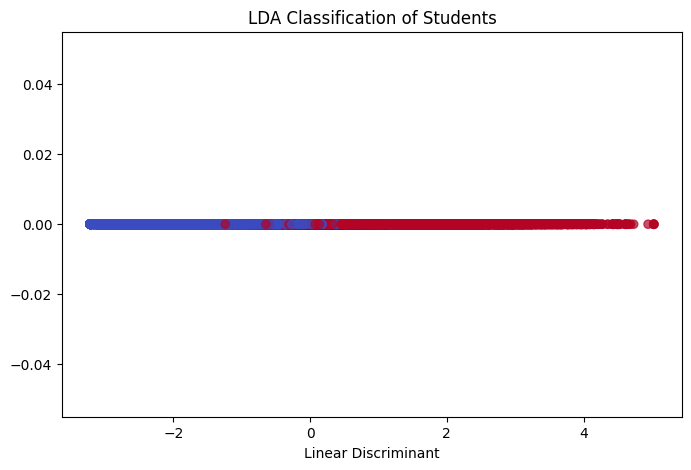

In [47]:
# Step 1: Create Categories
# Create target labels
df['Category'] = np.where(
    df['overall_score'] >= df['overall_score'].mean(),
    'Above Average',
    'Below Average'
)
print(df[['overall_score', 'Category']].head())

# Step 2: Encode Labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['Category'])

# Step 3: Select Features
X = df[['math_score',
          'science_score',
          'english_score']]

# Step 4: Apply LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)
print("\nLDA Fit Transform:\n", X_lda[:10])

# Step 5 Visualize LDA
plt.figure(figsize=(8,5))
plt.scatter(
    X_lda,
    np.zeros(len(X_lda)),
    c=y,
    cmap='coolwarm',
    alpha=0.7
)
plt.xlabel("Linear Discriminant")
plt.title("LDA Classification of Students")
plt.show()

### Interpretation:

- LDA finds the best single axis (linear discriminant) that separates the two groups.

- Each student’s score is transformed into one value along that axis.

- The scatter plot shows how well the groups are separated: red vs. blue points spread apart along the x-axis.